## Time to get your hands dirty! Supernova distances and redshifts (part 1)

*(exam guidelines available [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/exams.md))*


Measuring the cosmological relationship between distance and redshift is at the heart of the entire field of cosmology and allowed, among other things, the discovery of dark energy! At high redshifts, this is done with Type Ia Supernova which are standard (or better, standardizable) candles.

This is a [Nobel prize](https://www.nobelprize.org/prizes/physics/2011/riess/facts/) plot by [Riess et al](https://iopscience.iop.org/article/10.1086/300499)

![Screen%20Shot%202022-05-01%20at%2010.48.48.png](attachment:Screen%20Shot%202022-05-01%20at%2010.48.48.png)

Let's recall the definition of magnitude and the distance modulus (ah! the astronomers...)

$$
\mu = m-M =  5 \log_{10}\left(\frac{d_L}{\rm pc}\right) - 5
$$

Here is the Hubble diagram for Type Ia supernovae (which are standard candels). The lines show the predictions for cosmologies with varying amounts of Ωm and ΩΛ. The observed points all lie above the line for a universe with zero Λ. The lower panel, with the slope caused by the inverse square law taken out, shows the difference between the predictions more clearly and shows why a model with ΩΛ > 0 is favored. 

####  Tasks

- First, explore fitting this data with the tecniques we have seen.
- Start from linear regression and polynomial regression
- For the case of  polynomial regression, just fit many of them for now.
- Let's bet based on intuition! Which fit is the best?
- In what cases are you underfitting the data?
- In what cases are you overfitting the data?
- Now split the data into training and validation sets
- Implement a cross-validation procedure
- Pick the best!
- Does it agree with our bets?

#### OPTIONAL
- Repeat with Basis Function Regression and Kernel Regression
- Explore what happens when you change the number of datapoints and plot the resulting learning curves.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

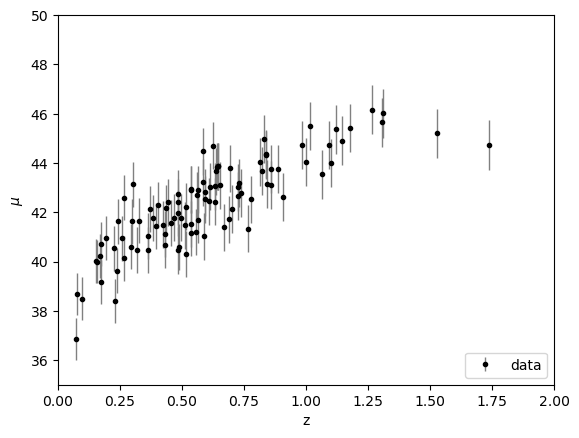

In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

## 1-D Linear Regression

In [14]:
# diagonal noise matrix
C = np.identity(len(z_sample)) * dmu**2

# design matrix
M = np.column_stack((np.ones(len(z_sample)), z_sample))

# Sigma^-1 = M^T * C^-1 * M
A = np.dot(np.dot(M.T, np.linalg.pinv(C)), M)

# M^T * C^-1 * y
B = np.dot(np.dot(M.T, np.linalg.pinv(C)), mu_sample)

# theta = Sigma * M^T * C^-1 * y
theta = np.dot(np.linalg.pinv(A),B)
print(theta)

[39.48384602  4.76438865]


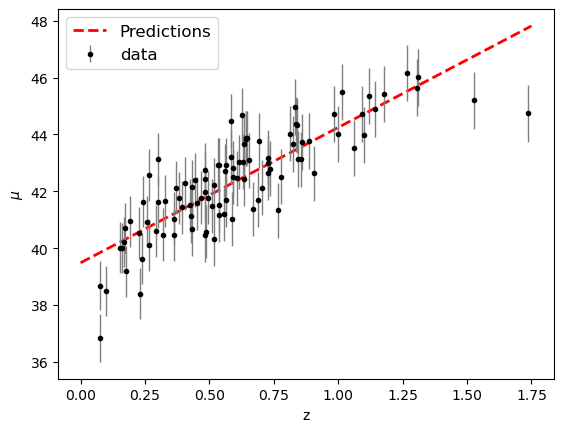

In [36]:
X_new = np.array([[0], [1.75]]) #like X_grid, but just with the endpoints
y_pred = theta[0] + theta[1]*X_new  # Complete 


plt.plot(X_new, y_pred, "r--", linewidth=2, label="Predictions")
#plt.plot(X_grid, y_true, "k-.", label="Actual") # Comment this out to see that it agrees with the above
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc="upper left", fontsize=12)
plt.show()

In [19]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(z_sample.reshape(-1,1), mu_sample, sample_weight=1.0)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)
y_pred2 = lin_reg.predict(X_new)

39.56505554722625 [4.64711848]


## Polynomial Regression

[39.56505555  4.64711848]
[38.44821027  8.49035585 -2.57760572]
[38.49130243  8.23905057 -2.20391808 -0.15168104]
[ 37.0543994   20.74217865 -32.83020744  27.30599762  -7.98337391]
[ 36.18760445  31.00142053 -69.82397489  82.84185044 -44.24104125
   8.47059008]
[  35.52810145   41.0777603  -119.2923833   190.65950213 -159.23341791
   67.07109508  -11.37900289]


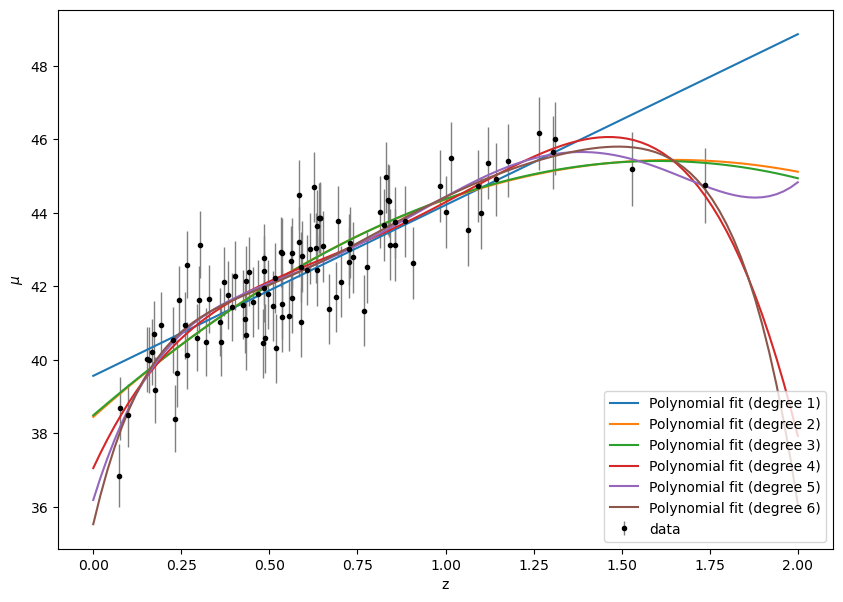

In [48]:
# Typical call
from astroML.linear_model import PolynomialRegression
plt.figure(figsize=(10, 7))
z_grid = np.linspace(0, 2, 100).reshape(-1, 1)


plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

degree = [1,2,3,4,5,6]

for d in degree:
    model = PolynomialRegression(d) # fit 3rd degree polynomial
    model.fit(z_sample.reshape(-1,1), mu_sample)
    
    y_pred = model.predict(z_sample.reshape(-1,1))
    n_constraints = d + 1
    
    print(model.coef_)
    y_grid = model.predict(z_grid)
    plt.plot(z_grid, y_grid, lw=1.5, label=f'Polynomial fit (degree {d})')
    
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc="lower right", fontsize=10)
plt.show()


## Cross Validation

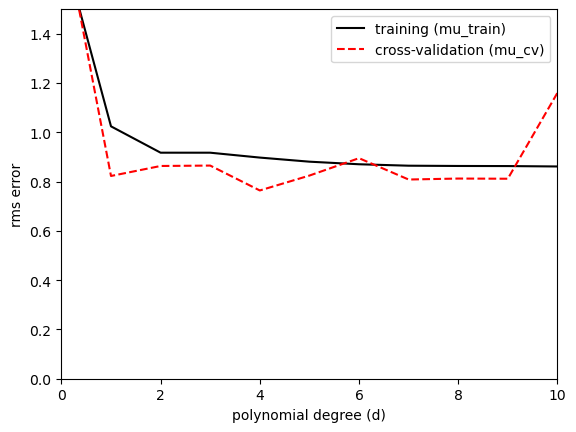

In [62]:
from sklearn.model_selection import train_test_split

z_train, z_cv, mu_train, mu_cv = train_test_split(z_sample, mu_sample, test_size=0.2)

d = np.arange(0, 11)
train_err = np.zeros(d.shape)
cv_err = np.zeros(d.shape)

for i in range(len(d)):
    model = PolynomialRegression(d[i])
    
    model.fit(z_train.reshape(-1, 1), mu_train)
    
    mu_train_pred = model.predict(z_train.reshape(-1, 1))
    train_err[i] = np.sqrt(np.mean((mu_train_pred - mu_train) ** 2))
    
    mu_cv_pred = model.predict(z_cv.reshape(-1, 1))
    cv_err[i] = np.sqrt(np.mean((mu_cv_pred - mu_cv) ** 2))


plt.plot(d, train_err, '-k', label='training (mu_train)')
plt
plt.plot(d, cv_err, '--r', label='cross-validation (mu_cv)')
plt
plt.xlim(0, 10)  
plt.ylim(0, 1.5) 
plt.xlabel('polynomial degree (d)')
plt.ylabel('rms error')
plt.legend(loc='upper right')

plt.show()